# Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
df1 = pd.read_excel('data_models.xlsx', sheet_name='dataset')
df2 = pd.read_excel('data_models.xlsx', sheet_name='models')
def clean_column_name(name):
    # Remove acentos
    name = unicodedata.normalize('NFKD', str(name)).encode('ASCII', 'ignore').decode('ASCII')
    # Lowercase
    name = name.lower()
    # Substitui espaços por underscore
    name = name.replace(' ', '_')
    # Remove caracteres não permitidos
    name = re.sub(r'[^\w_]', '', name)
    # Remove múltiplos underscores
    name = re.sub(r'__+', '_', name)
    # Remove underscores no início/fim
    name = name.strip('_')
    return name

df1.columns = [clean_column_name(col) for col in df1.columns]
df2.columns = [clean_column_name(col) for col in df2.columns]
df = pd.concat([
    df1[['diametro_da_armadura_f_mm', 'numero_de_barras_em_uma_camada', 
         'espacamento_entre_as_barras_mm', 'resistencia_a_tracao_do_concreto_fctm_mpa', 
         'cobrimento_c_mm', 'distancia_ao_centro_de_gravidade_da_armadura_d_mm', 'taxa_de_armadura_r', 
         'tensao_na_armadura_mpa', 'wexp_mm']], 
    df2[['fib_model_code_2010', 'caldas_1997', 'clark_1956','eurocode_2', 'slip_de_yuan_et_al_2025', 'slip_de_biscaia_e_soares_2020']]], axis=1)
df['error'] = df['wexp_mm'] - df['fib_model_code_2010']
df.head()

,diametro_da_armadura_f_mm,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_fctm_mpa,cobrimento_c_mm,distancia_ao_centro_de_gravidade_da_armadura_d_mm,taxa_de_armadura_r,tensao_na_armadura_mpa,wexp_mm,fib_model_code_2010,caldas_1997,clark_1956,eurocode_2,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,error
0,20.0,2,126.0,4.120341,25.0,39.0,0.060724,231.811005,0.16,0.125734,0.129998,0.181006,0.125292,0.109686,0.082007,0.034266
1,20.0,2,126.0,4.120341,25.0,39.0,0.060724,304.251944,0.23,0.176982,0.174746,0.244363,0.176359,0.193326,0.156266,0.053018
2,20.0,2,126.0,4.120341,25.0,39.0,0.060724,314.282228,0.24,0.184078,0.180941,0.253135,0.183430,0.205301,0.167096,0.055922
3,20.0,2,126.0,4.120341,25.0,39.0,0.060724,363.319171,0.27,0.218769,0.211232,0.296022,0.217999,0.265222,0.221958,0.051231
4,20.0,2,126.0,4.120341,25.0,39.0,0.060724,459.164106,0.35,0.286574,0.270437,0.379848,0.285566,0.388948,0.338382,0.063426


In [ ]:
df_model = df[['wexp_mm', 'taxa_de_armadura_r', 'slip_de_biscaia_e_soares_2020', 'cobrimento_c_mm', 'numero_de_barras_em_uma_camada', 'fib_model_code_2010', 'error', 'caldas_1997']]
df_model

,wexp_mm,taxa_de_armadura_r,slip_de_biscaia_e_soares_2020,cobrimento_c_mm,numero_de_barras_em_uma_camada,fib_model_code_2010,error,caldas_1997
0,0.16,0.060724,0.082007,25.0,2,0.125734,0.034266,0.129998
1,0.23,0.060724,0.156266,25.0,2,0.176982,0.053018,0.174746
2,0.24,0.060724,0.167096,25.0,2,0.184078,0.055922,0.180941
3,0.27,0.060724,0.221958,25.0,2,0.218769,0.051231,0.211232
4,0.35,0.060724,0.338382,25.0,2,0.286574,0.063426,0.270437
...,...,...,...,...,...,...,...,...
337,0.19,0.065570,0.266684,38.0,2,0.211435,-0.021435,0.208132
338,0.22,0.065570,0.310953,38.0,2,0.238730,-0.018730,0.233354
339,0.17,0.112443,0.182233,38.0,2,0.131534,0.038466,0.154484
340,0.19,0.111410,0.122579,38.0,2,0.097515,0.092485,0.116635


In [ ]:
df_model['error_pred_1'] = df_model['taxa_de_armadura_r'] + ((df_model['slip_de_biscaia_e_soares_2020'] * np.sin(df_model['cobrimento_c_mm'] / df_model['numero_de_barras_em_uma_camada'])) * -0.3149061)
df_model['error_pred_2'] = df_model['taxa_de_armadura_r'] - (df_model['caldas_1997'] * (df_model['slip_de_biscaia_e_soares_2020'] * np.sin(df_model['cobrimento_c_mm'] / df_model['numero_de_barras_em_uma_camada'])))

/tmp/ipykernel_62607/1117703158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.loc[:, 'error_pred_1'] = df_model['taxa_de_armadura_r'] + ((df_model['slip_de_biscaia_e_soares_2020'] * np.sin(df_model['cobrimento_c_mm'] / df_model['numero_de_barras_em_uma_camada'])) * -0.3149061)
/tmp/ipykernel_62607/1117703158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.loc[:, 'error_pred_2'] = df_model['taxa_de_armadura_r'] - (df_model['caldas_1997'] * (df_model['slip_de_biscaia_e_soares_2020'

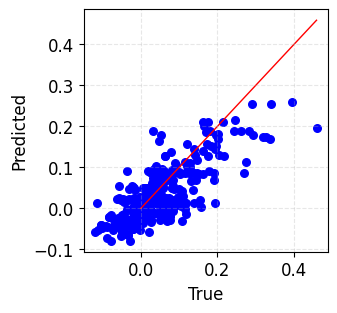

In [5]:
# Figure dimension
width_cm = 8
height_cm = 8
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

# Labels properties
label_x = 'True'
label_y = 'Predicted'
label_size = 12
axis_size = 12
label_color = 'black'

# Scatter Plot
point_size = 30
color_scatter = 'blue'
plt.figure(figsize=(width_in, height_in))
plt.scatter(df_model['error'], df_model['error_pred_1'],
            s=point_size,
            c=color_scatter)

# Regression Line
regression_line_color = 'red'
regression_line_style = '-'
regression_line_width = 1
x_line = np.array([0, max(df_model['error'])])
y_line = x_line
plt.plot(x_line, y_line,
         color=regression_line_color,
         linestyle=regression_line_style,
         linewidth=regression_line_width,
         zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel(label_x, fontsize=label_size, color=label_color)
plt.ylabel(label_y, fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
# plt.savefig('validation_scatter_train.png', dpi=600)

In [6]:
r2 = r2_score(df_model['error'], df_model['error_pred_1'])
print(f'R² score: {r2:.4f}')

R² score: 0.5712


In [7]:
r2 = r2_score(df_model['error'], df_model['error_pred_2'])
print(f'R² score: {r2:.4f}')

R² score: 0.5671


In [ ]:
df_model['wexp_new_pred_1'] = df_model['fib_model_code_2010'] + df_model['error_pred_1']
df_model['wnum_div_wexp'] = df_model['wexp_new_pred_1'] / df_model['wexp_mm']
r2 = r2_score(df_model['wexp_mm'], df_model['wexp_new_pred_1'])
print(f'R² score: {r2:.4f}')

R² score: 0.7481


/tmp/ipykernel_62607/1781362785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['wexp_new_pred_1'] = df_model['fib_model_code_2010'] + df_model['error_pred_2']
/tmp/ipykernel_62607/1781362785.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['wnum_div_wexp'] = df_model['wexp_new_pred_1'] / df_model['wexp_mm']


In [11]:
df_model.describe()

,wexp_mm,taxa_de_armadura_r,slip_de_biscaia_e_soares_2020,cobrimento_c_mm,numero_de_barras_em_uma_camada,fib_model_code_2010,error,caldas_1997,error_pred_1,error_pred_2,wexp_new_pred_1,wnum_div_wexp
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,0.261491,0.050929,0.238946,32.647807,2.497076,0.214343,0.047148,0.203577,0.036104,0.048467,0.262810,1.038362
std,0.114952,0.042848,0.109981,10.871746,1.365148,0.085954,0.087687,0.080628,0.066953,0.069272,0.109909,0.223979
min,0.140000,0.007960,0.038113,12.800000,1.000000,0.007169,-0.120411,0.058045,-0.078627,-0.072978,0.019964,0.099820
25%,0.190000,0.017479,0.167970,25.000000,2.000000,0.152824,-0.012940,0.153722,-0.017618,0.003465,0.204562,0.895215
50%,0.230000,0.044148,0.219838,30.000000,2.000000,0.204824,0.034885,0.185627,0.022088,0.027770,0.245956,1.029777
75%,0.300000,0.065231,0.292848,40.000000,3.750000,0.260060,0.081639,0.223297,0.082721,0.077397,0.282606,1.183916
max,0.790000,0.221883,0.676814,70.000000,9.000000,0.528081,0.458577,0.514817,0.258845,0.388590,0.791879,1.654387
